# Previsão de Falhas Estruturais Aplicadas no <span style="color:red;">Motor Brushless</span>

---

### Integrantes do grupo: 
- <span style="color:yellow;">Enrico Magalhães</span>;
-  Hugo Samuel;
- <span style="color:brown;">Vinícius Fernandes</span>;
- <span style="color:green;">Vitor Belo</span>.

### Parâmetros do grupo moto-propulsor utilizado: 
- *Motor:* Scorpion SII-4035-450
- *Hélice:* Master ...
- *Bateria:*
- **

---

### Repositório no Github: https://github.com/vitorvespoli/MachineLearning_Trabalho1

---

---


### Definição do problema

A SAE BRASIL é uma associação dedicada ao avanço da engenharia de mobilidade no país. Uma de suas principais iniciativas é o Projeto SAE BRASIL AeroDesign, um programa educacional que desafia estudantes universitários a conceber, projetar, construir e voar aeronaves rádio-controladas, simulando os mesmos desafios enfrentados pela indústria aeronáutica.

Na 26ª Competição SAE Brasil AeroDesign, uma falha no motor impediu o voo da equipe **Trem Ki Voa Micro** (equipe de competição da UFSJ) em uma de suas tentativas oficiais. O evento foi decisivo na pontuação final, resultando na obtenção do vice-campeonato nacional por uma margem de dois pontos em relação ao primeiro colocado.

A partir disso, surgiu a necessidade de desenvolver um modelo capaz de prever falhas com base nos dados de funcionamento do sistema, evitando que falhas passem despercebidas antes de um voo oficial. Dentre as inúmeras falhas que podem interferir no sistema, para a realização desse trabalho, foram escolhidas 3 falhas principais:

- Desbalanceamento de hélice;
- Hélice quebrada;
- Rotação invertida do motor.

## Imports:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import statistics as st

### Função para plotar os gráficos

In [6]:
import matplotlib.pyplot as plt

def plot_technical(
    x,
    y,
    title="Título do Gráfico",
    xlabel="Eixo X",
    ylabel="Eixo Y",
    labels=None,
    linewidth=2.0,
    markers=None,
    figsize=(8, 5),
    grid=True,
    save=False,
    filename="grafico.png",
    dpi=300
):
    """
    Plota gráficos com estilo apropriado para relatórios técnicos.

    Parâmetros
    ----------
    x : array-like
        Vetor do eixo x.
    y : array-like ou lista de array-like
        Vetor y ou lista de vetores y para múltiplas curvas.
    title : str
        Título do gráfico.
    xlabel : str
        Rótulo do eixo x.
    ylabel : str
        Rótulo do eixo y.
    labels : list[str] ou None
        Legendas das curvas.
    linewidth : float
        Espessura das linhas.
    markers : list[str] ou None
        Marcadores para cada curva, ex: ['o', 's', '^'].
    figsize : tuple
        Tamanho da figura.
    grid : bool
        Ativa/desativa a grade.
    save : bool
        Se True, salva a figura.
    filename : str
        Nome do arquivo para salvar.
    dpi : int
        Resolução da imagem salva.
    """

    plt.figure(figsize=figsize)

    if not isinstance(y[0], (list, tuple)) and not hasattr(y[0], "__len__"):
        y = [y]

    n_curves = len(y)

    if labels is None:
        labels = [f"Curva {i+1}" for i in range(n_curves)]

    if markers is None:
        markers = [None] * n_curves

    for i in range(n_curves):
        plt.plot(
            x,
            y[i],
            label=labels[i],
            linewidth=linewidth,
            marker=markers[i]
        )

    plt.title(title, fontsize=13)
    plt.xlabel(xlabel, fontsize=11)
    plt.ylabel(ylabel, fontsize=11)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)

    if grid:
        plt.grid(True, linestyle='--', alpha=0.7)

    if labels is not None:
        plt.legend(fontsize=10)

    plt.tight_layout()

    if save:
        plt.savefig(filename, dpi=dpi, bbox_inches='tight')

    plt.show()

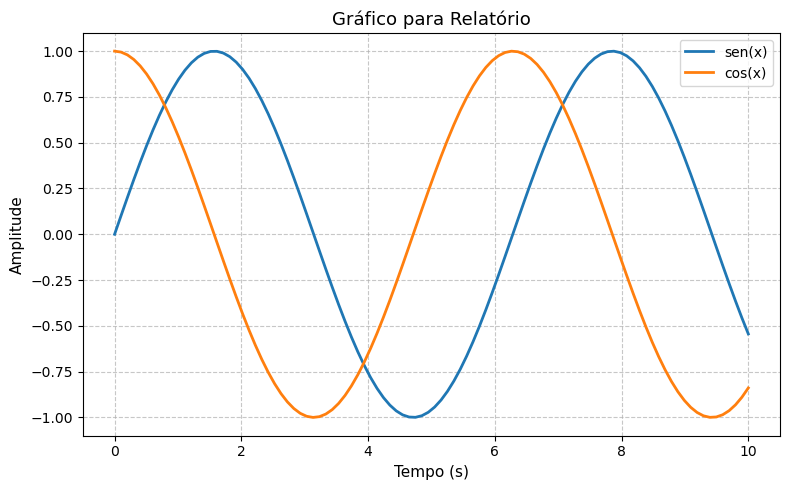

In [ ]:
import numpy as np

x = np.linspace(0, 10, 100)
y1 = np.sin(x)
y2 = np.cos(x)

plot_technical(
    x,
    [y1, y2],
    title="Plot Cos e Sen",
    xlabel="Tempo (s)",
    ylabel="Amplitude",
    labels=["sen(x)", "cos(x)"],
    save=True,
    filename="grafico_1.png"
)

In [23]:
# Aqui o código pega o diretório das pastas em que os arquivos estão
thisFolder = os.getcwd()
dataFolder = os.path.join(thisFolder, "dados_coletados")

# Seleciona as pastas de cada operação (operação normal e falhas)
desbalanceadaFolder = os.path.join(dataFolder, "helice_desbalanceada")
quebradaFolder = os.path.join(dataFolder, "helice_quebrada")
normalFolder = os.path.join(dataFolder, "normal")
invertidaFolder = os.path.join(dataFolder, "rotacao_invertida")

folders = {
    "normal": normalFolder,
    "desbalanceada": desbalanceadaFolder,
    "quebrada": quebradaFolder,
    "invertida": invertidaFolder
    
}

## Análise Estatística
Após a coleta e tratamento dos dados, esses foram segmentados em duas seções de transitórios (transitório inicial e final) e uma seção de regime estacionário, em que o manche do motor permanece no limite máximo, corroborando no máximo consumo de potência disponível conforme as capacidades do sistema.

A função abaixo realiza a identificação dessas seções. Primeiramente, há a aquisição da média referente aos valores entre 25% e 75% dos dados (seção aproximada de regime permanente), após isso, o algoritmo realiza uma varredura nas linhas dos dados de corrente em Ampères, sendo um dos principais parâmetros direcionados ao comportamento do sistema. A varredura ocorre visando encontrar os pontos de chaveamento de seções. O chaveamento entre o transitório inicial e o regime permanente é quando há o encontro de um dado entre 90 e 130% da média obtida. Já o chaveamento entre o regime permanente e o transitório final ocorre quando há o encontro de um dado abaixo de 82% do valor da média obtida. A busca pelo ponto de chaveamento entre o regime permanente e transitório final ocorre somente se o primeiro ponto de chaveamento já estiver obtido. Os valores de chaveamento foram obtidos a partir de testes.

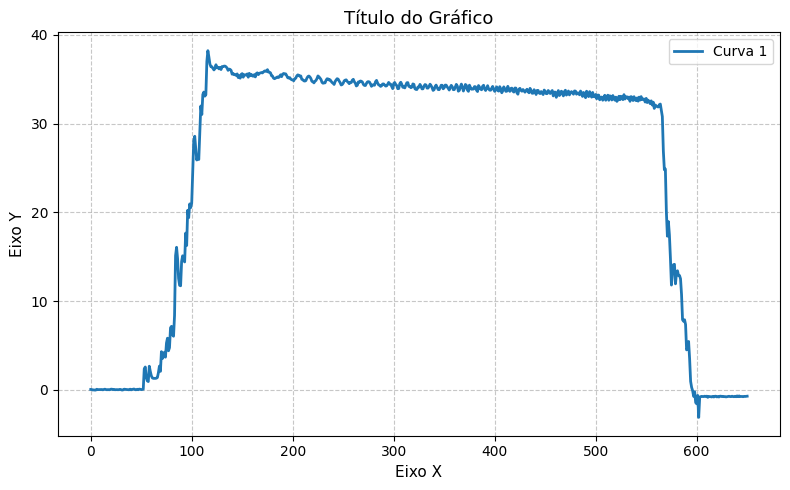

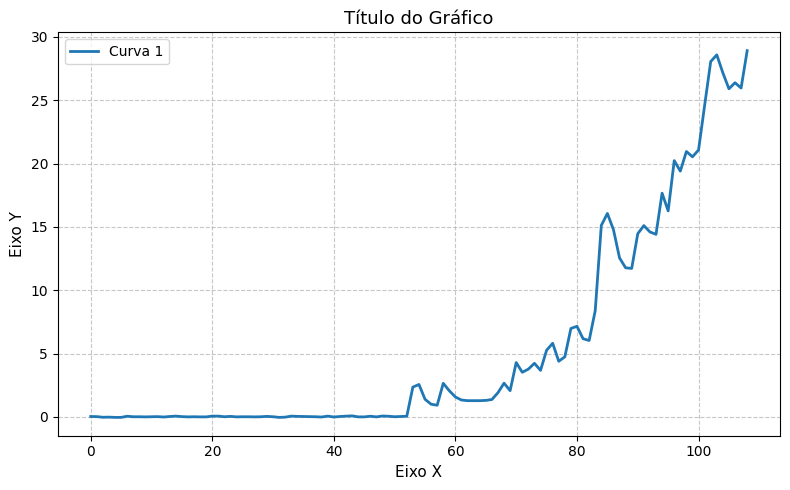

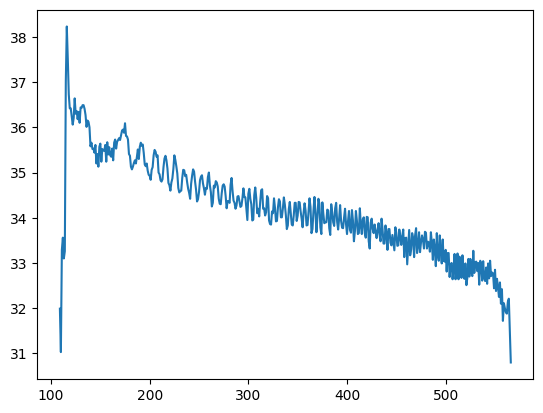

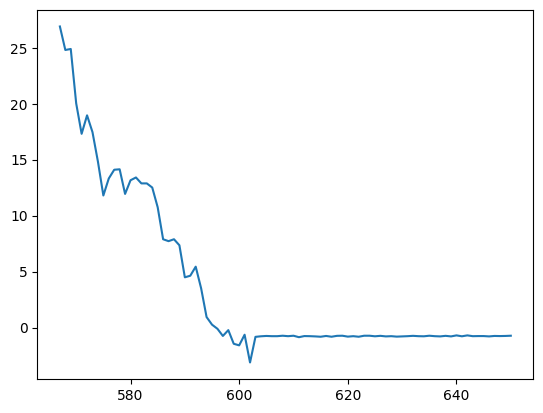

In [22]:
def transitory_stacionary(df):
    
    loc_i = df.columns.get_loc("Corrente_A") + 1

    q1 = df["Corrente_A"].quantile(0.25)
    q3 = df["Corrente_A"].quantile(0.75)

    df_50 = df[(df["Corrente_A"] >= q1) & (df["Corrente_A"] <= q3)]

    flag_stac = False
    transitory_2 = None
    flag_transitory_1 = True

    median = df_50["Corrente_A"].mean()
    

    for idx, row in enumerate(df.itertuples()):
        if ((np.abs(row[loc_i]) >= 0.93*median) & (np.abs(row[loc_i]) <= 1.3*median) & flag_transitory_1):
            transitory_1 = idx
            flag_stac = True
            flag_transitory_1 = False
            
        if flag_stac:
            if ((np.abs(row[loc_i]) <= 0.9*median)):
                transitory_2 = idx
                break

    df_0 = df.iloc[:transitory_1]
    if transitory_2 != None:
        df_1 = df.iloc[transitory_1:transitory_2]
        df_2 = df.iloc[transitory_2:]
    else:
        df_1 = df.iloc[transitory_1:]
        df_2 = None

    return df_0, df_1, df_2

df_ex = pd.read_excel(os.path.join(quebradaFolder, "helice_quebrada_2.xlsx"))
df0, df1, df2 = transitory_stacionary(df_ex)

plot_technical(df_ex.index, df_ex["Corrente_A"])
plot_technical(df0.index, df0["Corrente_A"])
plt.figure()
plt.plot(df1.index, df1["Corrente_A"])

plt.figure()
plt.plot(df2.index, df2["Corrente_A"])
plt.show()
#plot_technical(df1.index, df1["Corrente_A"])
#plot_technical(df2.index, df2["Corrente_A"])

In [24]:
class statisticsParams:
    def __init__(self, name = None, df = None, tr1_qty = None, regime_qty = None, tr2_qty = None):
        
        mean = {}
        median = {}
        max = {}
        min = {}
        desv_padr = {}
        skew = {}
        kurtosis = {}

        if df is not None:
            header = df.columns.to_list()    

            for h in header:
                mean[h] = df[h].mean()
                median[h] = df[h].median()
                max[h] = df[h].max()
                min[h] = df[h].min()
                desv_padr[h] = st.stdev(df[h])
                skew[h] = df[h].skew()
                kurtosis[h] = df[h].kurtosis()

            self.name = name
            self.header = header
            self.mean = mean
            self.median = median
            self.max = max
            self.min = min
            self.desv_padr = desv_padr
            self.skew = skew
            self.kurtosis = kurtosis

            self.tr1_qty = tr1_qty
            self.regime_qty = regime_qty
            self.tr2_qty = tr2_qty

        else:
            self.name = ""
            self.mean = mean
            self.median = median
            self.max = max
            self.min = min
            self.desv_padr = desv_padr
            self.skew = skew
            self.kurtosis = kurtosis

            self.tr1_qty = 0
            self.regime_qty = 0
            self.tr2_qty = 0

In [25]:
def statisticsGroup(ops, name):
    header = ops[0].header
    
    stat_temp = statisticsParams()
    

    for h in header:
        tr1_qty = 0
        tr2_qty = 0
        regime_qty = 0

        mean = []
        median = []
        maximum = []
        minimum = []
        desv_padrao = []
        skew = []
        kurtosis = []

        for op in ops:
            tr1_qty += op.tr1_qty
            tr2_qty += op.tr2_qty
            regime_qty += op.regime_qty

            mean.append(op.mean[h])
            median.append(op.median[h])
            maximum.append(op.max[h])
            minimum.append(op.min[h])
            desv_padrao.append(op.desv_padr[h])
            skew.append(op.skew[h])
            kurtosis.append(op.kurtosis[h])

        
        stat_temp.mean[h] = st.mean(mean)
        stat_temp.median[h] = st.mean(median)
        stat_temp.max[h] = max(maximum)
        stat_temp.min[h] = min(minimum)
        stat_temp.desv_padr[h] = st.mean(desv_padrao)
        stat_temp.skew[h] = st.mean(skew)
        stat_temp.kurtosis[h] = st.mean(kurtosis)
    
    stat_temp.name = name
    stat_temp.header = header
    stat_temp.tr1_qty = tr1_qty
    stat_temp.tr2_qty = tr2_qty
    stat_temp.regime_qty = regime_qty

    return stat_temp

In [26]:
def stats_dataFrame(class_param):
    
    resumo = pd.DataFrame({
            "parameter": (h for h in class_param.header),
            "media": (class_param.mean[h] for h in class_param.header),
            "median": (class_param.median[h] for h in class_param.header),
            "maximum": (class_param.max[h] for h in class_param.header),
            "minimum": (class_param.min[h] for h in class_param.header),
            "desvio_padrao": (class_param.desv_padr[h] for h in class_param.header),
            "skewness": (class_param.skew[h] for h in class_param.header),
            "kurtosis": (class_param.kurtosis[h] for h in class_param.header)
        })
    
    print("transitorio 1, quantidade de dados = ", class_param.tr1_qty)
    print("regime, quantidade de dados = ", class_param.regime_qty)
    print("transitorio 2, quantidade de dados = ", class_param.tr2_qty)
    print(resumo)

Como foram realizadas múltiplas aquisições para cada tipo de operação, com exceção dos máximos e mínimos, o restante dos parâmetros abaixo são apresentados como a média entre as aquisições de cada operação. 

Abaixo contém um resumo com parâmetros relevantes para a análise desejada, como a quantidade total de pontos em cada intervalo de operação após o ajuste dos dados.

In [27]:

for fold in folders:
    df1s = []

    op_1s = []
    op_0s = []
    op_2s = []
    
    regime_qty = 0
    tr1_qty = 0
    tr2_qty = 0

    print("")
    print("=============", fold, "=============")

    files_temp = [os.path.join(folders[fold], x) for x in os.listdir(folders[fold]) if x.endswith(".xlsx")]

    # Cria uma lista com todos os DataFrames contidos na pasta atual
    dfs = [pd.read_excel(f) for f in files_temp]

    # Acessa cada DataFrame da lista de DataFrames da pasta atual
    for i, df_i in enumerate(dfs):

        df_i = df_i.drop(columns="Celula3_Kgf")
        df_i = df_i.drop(columns="Tempo")
        df_i = df_i.drop(columns="RPM")
       
        df_0, df_1, df_2 = transitory_stacionary(df_i)

        tr1_qty += len(df_0)
        regime_qty += len(df_1)
        tr2_qty += len(df_2)

        df1s.append(df_1)

        
        op_1 = statisticsParams((fold)+f"_{i}", df_1, tr1_qty, regime_qty, tr2_qty)
        op_1s.append(op_1)

    op_1_total = statisticsGroup(op_1s, fold)
    stats_dataFrame(op_1_total)


============= normal =============
transitorio 1, quantidade de dados =  691
regime, quantidade de dados =  857
transitorio 2, quantidade de dados =  2283
     parameter        media       median    maximum   minimum  desvio_padrao  \
0  Celula1_Kgf  -530.737589  -531.000000  -445.0000  -683.000       9.126974   
1  Celula2_Kgf  2118.820725  2147.166667  3047.0000  1291.000      91.124709   
2     Tensao_V    14.131371    14.130000    14.7300    12.850       0.086156   
3   Corrente_A    28.354740    28.318333    31.5700    23.860       0.781325   
4   Potencia_W   400.646669   399.565233   442.1946   307.794      11.560435   

   skewness  kurtosis  
0       NaN       NaN  
1       NaN       NaN  
2       NaN       NaN  
3       NaN       NaN  
4       NaN       NaN  

============= desbalanceada =============
transitorio 1, quantidade de dados =  1007
regime, quantidade de dados =  2455
transitorio 2, quantidade de dados =  715
     parameter        media       median   maximum    m

Observando os valores referentes à tração, com exceção do caso de hélice desbalanceada, nota-se que o caso de operação normal contém maior valor em média, seguido por hélice quebrada e rotação invertida. No caso de rotação invertida, houve troca de sentido da força, como esperado.

Para a situação de hélice desbalanceada, apesar de conter maior valor de tração em relação à operação normal, houve maior desvio padrão, o que indica variabilidade dos dados de tração em relação ao valor médio, um fator também esperado pela distribuição assimétrica de inércia no plano do eixo da hélice.